<a href="https://colab.research.google.com/github/chummi07/Machine_Learning_Projects/blob/main/CAB_FARE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#generate fake uber data for 500 rides
np.random.seed(42)
distance_km = np.random.uniform(1,20,500)

#Price is roughly 15 rupees per km, + a base fare of 40, +some random traffic noise
actual_price =(distance_km*15)+40+np.random.normal(0,20,500)
uber_data=pd.DataFrame({'distance_KM':distance_km,'price_INR':actual_price})
print("here is our uber database:")
print(uber_data.head())


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
distance_km = np.random.uniform(1,20,500)
actual_price =(distance_km*15)+40+np.random.normal(0,20,500)
uber_data=pd.DataFrame({'distance_KM':distance_km,'price_INR':actual_price})
print("here is our uber database:")
print(uber_data.head())




here is our uber database:
   distance_KM   price_INR
0     8.116262  168.579053
1    19.063572  363.476994
2    14.907885  282.626750
3    12.374511  214.079595
4     3.964354   81.497019


The AI predicts a 10km ride will cost: Rs.190.04


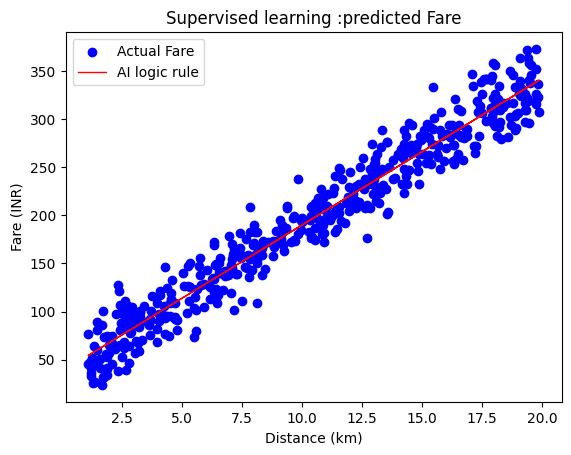

In [7]:
from sklearn.linear_model import LinearRegression

X=uber_data[['distance_KM']]
y=uber_data['price_INR']

price_model=LinearRegression()
price_model.fit(X,y)

new_ride=pd.DataFrame({'distance_KM': [10]})
predicted_fare=price_model.predict(new_ride)

print(f"The AI predicts a 10km ride will cost: Rs.{predicted_fare[0]:.2f}")
plt.scatter(X,y,color='blue',alpha=1,label='Actual Fare')
plt.plot(X,price_model.predict(X),color='red',linewidth=1,label='AI logic rule')
plt.title("Supervised learning :predicted Fare")
plt.xlabel("Distance (km)")
plt.ylabel("Fare (INR)")
plt.legend()
plt.show()

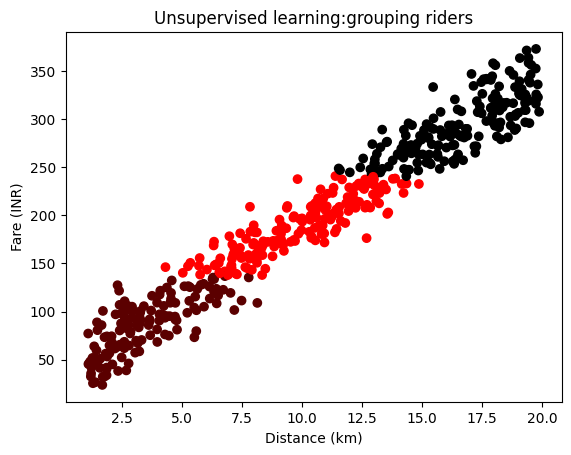

In [10]:
from sklearn.cluster import KMeans

data_for_clustering = uber_data[['distance_KM','price_INR']]


clustering_model = KMeans(n_clusters=3,random_state=42,n_init=10)
uber_data['Rider_Type']=clustering_model.fit_predict(data_for_clustering)

plt.scatter(uber_data['distance_KM'],uber_data['price_INR'],c=uber_data['Rider_Type'],cmap='flag_r')
plt.title("Unsupervised learning:grouping riders")
plt.xlabel("Distance (km)")
plt.ylabel("Fare (INR)")
plt.show()

In [11]:
import random

surge_options = [1.0,1.5,2.0]
ai_memory_rewards=[0,0,0]
times_tried=[0,0,0]

print("AI is learning the best surge price by trial and error..\n")

for ride in range(100):
  action_index=random.randint(0,2)
  choosen_surge=surge_options[action_index]

  if choosen_surge==1.0:
    reward = 50
  elif choosen_surge==1.5:
    reward = 75 if random.random() > 0.2 else 0
  elif choosen_surge==2.0:
    reward = 100 if random.random() > 0.6 else 0

  ai_memory_rewards[action_index]+=reward
  times_tried[action_index]+=1
average_rewards=[ai_memory_rewards[i]/(times_tried[i]+ 1) for i in range(3)]

for i in range(3):
  print(f"Surge {surge_options[i]} X earned an average of ${average_rewards[i]:.2f} per ride.")

best_action=surge_options[np.argmax(average_rewards)]
print(f"\nReinforcement Learning Complete.AI sets final surge to :{best_action}X")




AI is learning the best surge price by trial and error..

Surge 1.0 X earned an average of $48.61 per ride.
Surge 1.5 X earned an average of $64.02 per ride.
Surge 2.0 X earned an average of $46.15 per ride.

Reinforcement Learning Complete.AI sets final surge to :1.5X
